<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula12a_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz
!rm -r aclImdb/train/unsup
!cat aclImdb/train/pos/4077_10.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  9850k      0  0:00:08  0:00:08 --:--:-- 13.7M
I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drin

In [3]:
import os, pathlib, shutil, random
base_dir = pathlib.Path("aclImdb")
train_dir = base_dir / "train"
val_dir = base_dir / "val"
test_dir = base_dir / "test"
for category in ["pos", "neg"]:
  os.makedirs(val_dir / category)
  files = os.listdir(train_dir / category)
  random.shuffle(files)
  num_val_samples = int(0.2 * len(files))
  val_files = files[-num_val_samples:]
  for fname in val_files:
    shutil.move(train_dir / category / fname, val_dir / category / fname)

In [4]:
from tensorflow import keras

batch_size = 32
train_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/train", batch_size=batch_size)
val_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/val", batch_size=batch_size)
test_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/test", batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


In [5]:
from tensorflow.keras.layers import TextVectorization
max_length = 600
max_tokens=20000
text_vectorization = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length)
text_only_train_ds = train_ds.map(lambda x, y: x)
text_vectorization.adapt(text_only_train_ds)
int_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=4)
int_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=4)
int_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=4)

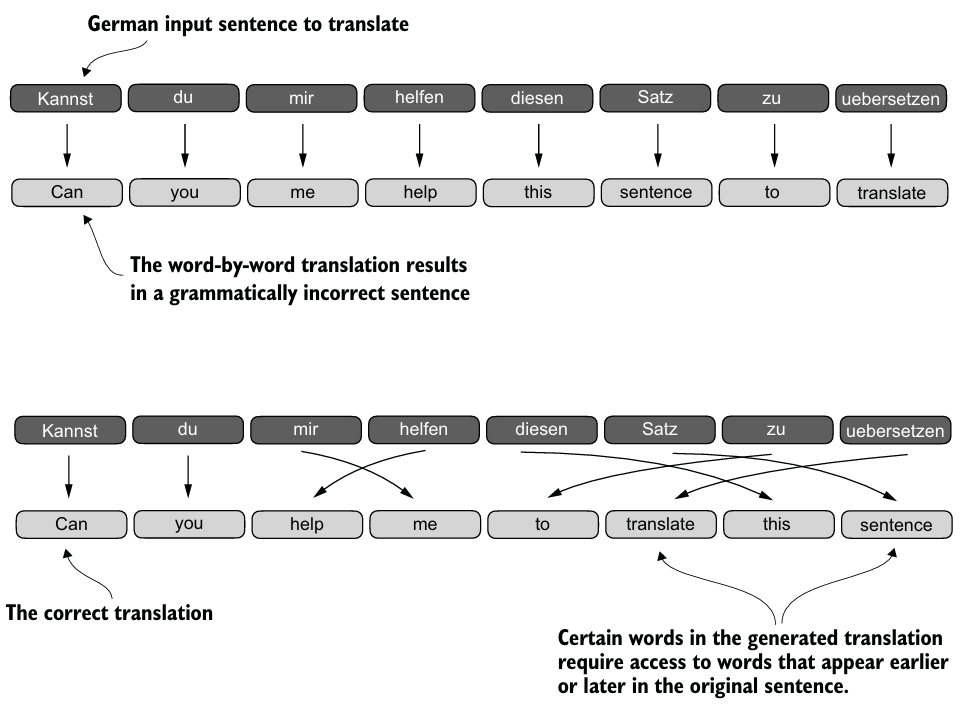

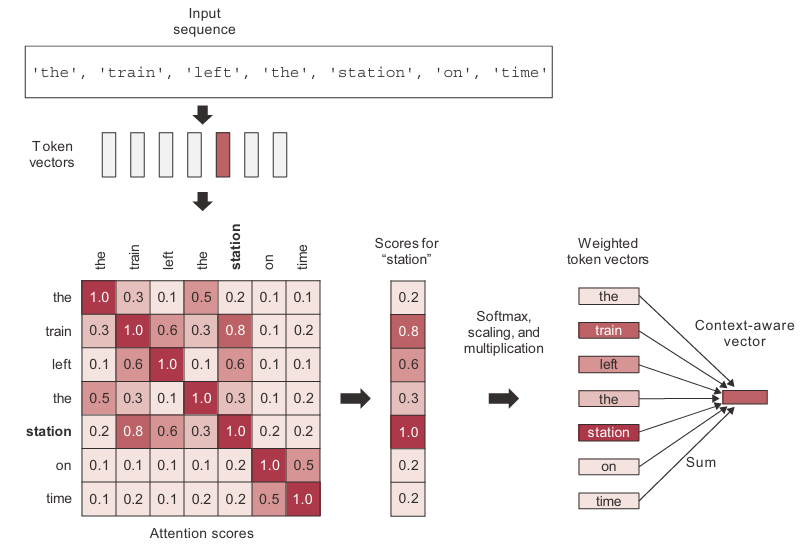

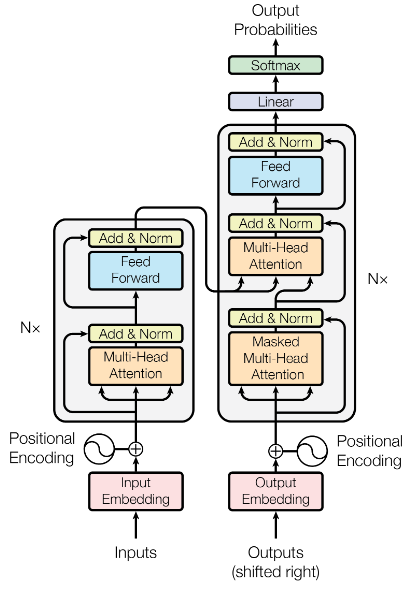

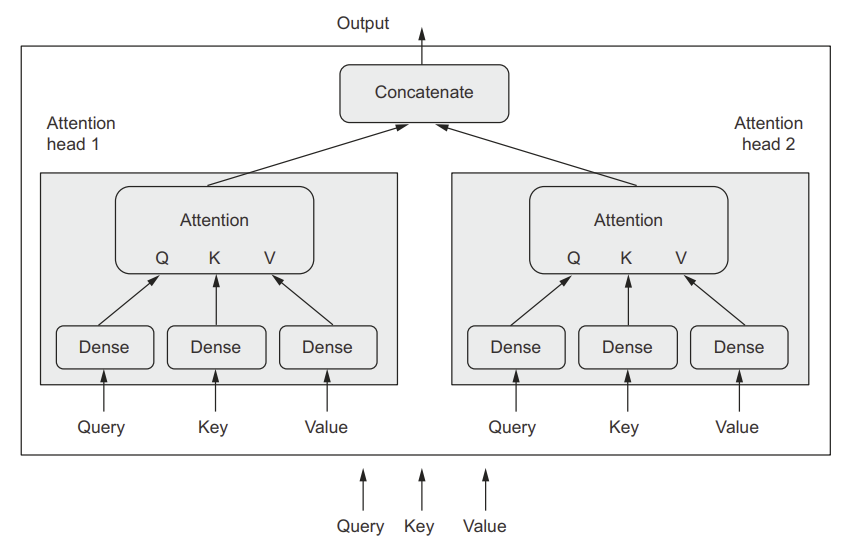

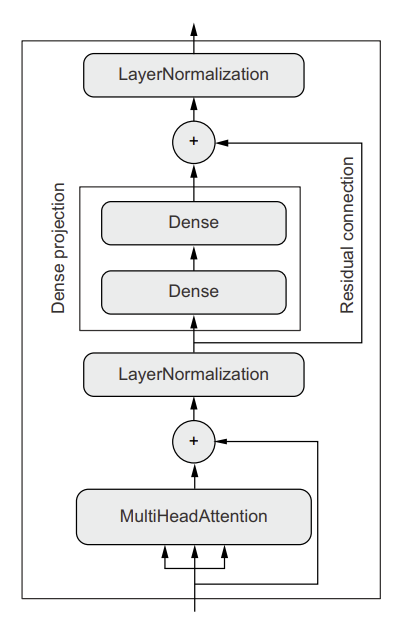

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class TransformerEncoder(layers.Layer):
  def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
    super(TransformerEncoder, self).__init__(**kwargs)
    self.embed_dim = embed_dim
    self.dense_dim = dense_dim
    self.num_heads = num_heads
    self.attention = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim)
    self.dense_proj = keras.Sequential(
        [layers.Dense(dense_dim, activation="relu"),
         layers.Dense(embed_dim),]
    )
    self.layernorm_1 = layers.LayerNormalization()
    self.layernorm_2 = layers.LayerNormalization()

  def call(self, inputs, mask=None):
    if mask is not None:
      mask = tf.cast(mask[:, :, tf.newaxis], dtype=tf.int32)
    attention_output = self.attention(
        query=inputs, value=inputs, key=inputs, attention_mask=mask)
    proj_input = self.layernorm_1(inputs + attention_output)
    proj_output = self.dense_proj(proj_input)
    return self.layernorm_2(proj_input + proj_output)

  def get_config(self):
    config = super().get_config()
    config.update({
        "embed_dim": self.embed_dim,
        "num_heads": self.num_heads,
        "dense_dim": self.dense_dim,
    })
    return config

In [12]:
vocab_size = 20000
embed_dim = 256
num_heads = 2
dense_dim = 32
inputs = keras.Input(shape=(None,), dtype="int32")
x = layers.Embedding(vocab_size, embed_dim)(inputs)
x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
x = layers.GlobalMaxPool1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 256)      │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, None, 256)      │       543,776 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,664,033 (21.61 MB)

 Trainable params: 5,664,033 (21.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks = [
    keras.callbacks.ModelCheckpoint("transformer_encoder.keras",
                                    save_best_only=True)
]
model.fit(int_train_ds, validation_data=int_val_ds, epochs=10, callbacks=callbacks)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 148ms/step - accuracy: 0.6582 - loss: 0.6373 - val_accuracy: 0.7974 - val_loss: 0.4289
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 146ms/step - accuracy: 0.8273 - loss: 0.3900 - val_accuracy: 0.8464 - val_loss: 0.3431
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 145ms/step - accuracy: 0.8523 - loss: 0.3412 - val_accuracy: 0.8598 - val_loss: 0.3147
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 145ms/step - accuracy: 0.8701 - loss: 0.3096 - val_accuracy: 0.8680 - val_loss: 0.2978
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.8803 - loss: 0.2855 - val_accuracy: 0.8656 - val_loss: 0.3066
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.8935 - loss: 0.2603 - val_accuracy: 0.8752 - val_loss: 0.2916
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 143ms/step - accuracy: 0.9037 - loss: 0.2397 - val_accuracy: 0.8744 - val_loss: 0.2977
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 142ms/step - accuracy: 0.9125 - loss: 

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
model = keras.models.load_model(
    "transformer_encoder.keras",
    custom_objects={"TransformerEncoder": TransformerEncoder})
results = model.evaluate(int_test_ds)
print(results)

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.8652 - loss: 0.3201
[0.3200603425502777, 0.8651999831199646]


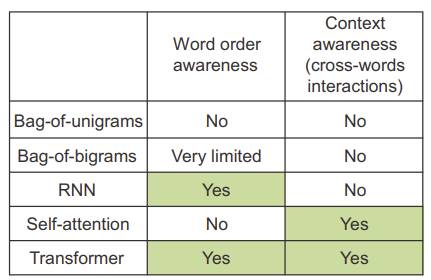

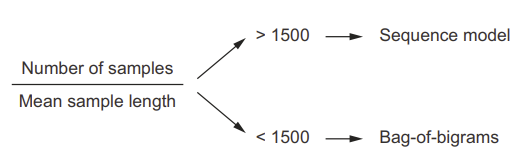

## Diferença entre "layer normalization" e "batch normalization"

In [10]:
def layer_normalization(batch_of_sequences):
  mean = batch_of_sequences.mean(axis=-1, keepdims=True)
  std = batch_of_sequences.std(axis=-1, keepdims=True)
  return (batch_of_sequences - mean) / std

def batch_normalization(batch_of_sequences):
  mean = batch_of_sequences.mean(axis=(0, 1), keepdims=True)
  std = batch_of_sequences.std(axis=(0, 1), keepdims=True)
  # Avoid division by zero for constant features
  std = np.where(std == 0, 1e-8, std)
  return (batch_of_sequences - mean) / std

In [11]:
import numpy as np

# Create a sample batch of sequences
# Let's imagine a batch of 2 sequences, each with 3 timesteps and 4 features
batch_of_sequences = np.array([
    [[1.0, 2.0, 3.0, 4.0],
     [5.0, 6.0, 7.0, 8.0],
     [9.0, 10.0, 11.0, 12.0]],

    [[10.0, 20.0, 30.0, 40.0],
     [50.0, 60.0, 70.0, 80.0],
     [90.0, 100.0, 110.0, 120.0]]
])

print("Original Batch of Sequences:")
print(batch_of_sequences)
print("Shape:", batch_of_sequences.shape)
print("\n" + "-"*50 + "\n")

# Apply Layer Normalization
# Layer normalization normalizes across the feature dimension (last axis) for each sequence independently.
normalized_by_layer = np.array([layer_normalization(seq) for seq in batch_of_sequences])

print("Layer Normalization Result:")
print(normalized_by_layer)
print("Mean of each original sequence (should be close to 0 after layer norm):")
print([np.mean(seq, axis=-1) for seq in normalized_by_layer])
print("Std dev of each original sequence (should be close to 1 after layer norm):")
print([np.std(seq, axis=-1) for seq in normalized_by_layer])
print("\n" + "-"*50 + "\n")

# Apply Batch Normalization
# Batch normalization normalizes across the batch and timestep dimensions for each feature independently.
# For a 3D array (batch, timesteps, features), mean and std are calculated across axes (0, 1).
normalized_by_batch = batch_normalization(batch_of_sequences)

print("Batch Normalization Result (per feature across batch/timesteps):")
print(normalized_by_batch)
print("Mean of each feature across batch and timesteps (should be close to 0 after batch norm):")
print(np.mean(normalized_by_batch, axis=(0, 1)))
print("Std dev of each feature across batch and timesteps (should be close to 1 after batch norm):")
print(np.std(normalized_by_batch, axis=(0, 1)))


Original Batch of Sequences:
[[[  1.   2.   3.   4.]
  [  5.   6.   7.   8.]
  [  9.  10.  11.  12.]]

 [[ 10.  20.  30.  40.]
  [ 50.  60.  70.  80.]
  [ 90. 100. 110. 120.]]]
Shape: (2, 3, 4)

--------------------------------------------------

Layer Normalization Result:
[[[-1.34164079 -0.4472136   0.4472136   1.34164079]
  [-1.34164079 -0.4472136   0.4472136   1.34164079]
  [-1.34164079 -0.4472136   0.4472136   1.34164079]]

 [[-1.34164079 -0.4472136   0.4472136   1.34164079]
  [-1.34164079 -0.4472136   0.4472136   1.34164079]
  [-1.34164079 -0.4472136   0.4472136   1.34164079]]]
Mean of each original sequence (should be close to 0 after layer norm):
[array([0., 0., 0.]), array([0., 0., 0.])]
Std dev of each original sequence (should be close to 1 after layer norm):
[array([1., 1., 1.]), array([1., 1., 1.])]

--------------------------------------------------

Batch Normalization Result (per feature across batch/timesteps):
[[[-0.81979459 -0.87068118 -0.90730348 -0.93385921]
  [-0.